In [1]:
# Load outputs from the previous notebook.
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("/content")
INTERMEDIATE_FILE = DATA_DIR / "data_preparation_outputs.pkl"

with open(INTERMEDIATE_FILE, "rb") as file:
    data_preparation_outputs = pickle.load(file)

globals().update(data_preparation_outputs)

print("Loaded:", INTERMEDIATE_FILE)

Loaded: /content/data_preparation_outputs.pkl


# Feature Group Experiments

## Experiment A: Voltage and Historical Features

Experiment A uses five voltage and previous-cycle features. The same 34 cells and cycle-cell observations are retained in Experiments A, B and C.


### Feature Engineering

In [2]:
# Create one feature row for each cell in each retained WLTP cycle.
feature_records = []

for file_name in retained_wltp_file_names:

    file_path = DATA_DIR / file_name

    df = pd.read_parquet(
        file_path,
        columns=["Semicycle", *cell_voltage_columns]
    )

    wltp = df[df["Semicycle"] == "WLTP"].copy()

    if len(wltp) == 0:
        continue

    cycle_number = int(file_name.split("_")[2])

    # Use pack-average cell voltage as the reference.
    pack_voltage_mean = wltp[cell_voltage_columns].mean(axis=1)

    lowest_voltage_cell = wltp[cell_voltage_columns].idxmin(axis=1)

    for cell in cell_ids:

        voltage_column = f"Voltage_Cell_{cell} [V]"

        feature_records.append({
            "cycle": cycle_number,
            "cell": cell,
            "voltage_mean": wltp[voltage_column].mean(),
            "voltage_min": wltp[voltage_column].min(),

            # Measure the average absolute difference from the pack voltage reference.
            "voltage_deviation": (
                wltp[voltage_column] - pack_voltage_mean
            ).abs().mean(),

            # Measure how often the cell has the lowest voltage in the cycle.
            "lowest_voltage_frequency": (
                lowest_voltage_cell == voltage_column
            ).mean() * 100
        })

base_feature_df = (
    pd.DataFrame(feature_records)
    .sort_values(["cell", "cycle"])
    .reset_index(drop=True)
)

print("Feature table shape:", base_feature_df.shape)

display(
    base_feature_df
    .head(10)
    .round(4)
)

Feature table shape: (11340, 6)


,cycle,cell,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency
0,2,P1S1,4.1673,4.006,0.0152,0.5833
1,3,P1S1,3.9796,3.504,0.0550,0.0000
2,4,P1S1,4.0199,3.565,0.0567,0.0000
3,5,P1S1,4.0091,3.416,0.0570,0.0000
4,6,P1S1,3.9418,3.499,0.0333,0.0000
5,7,P1S1,3.9558,3.504,0.0361,0.0000
6,8,P1S1,3.8553,3.305,0.0389,0.0313
7,9,P1S1,3.9013,3.351,0.0447,0.5543
8,10,P1S1,3.9071,3.241,0.0423,0.0000
9,11,P1S1,3.8994,3.397,0.0343,0.0000


#### Temporal Feature

The change in voltage deviation from the previous retained WLTP cycle provides the history feature.


In [3]:
# Add previous-WLTP-cycle change in voltage deviation,
base_feature_df["voltage_deviation_change"] = (
    base_feature_df
    .groupby("cell")["voltage_deviation"]
    .diff()
)

print(
    "Missing history values:",
    base_feature_df["voltage_deviation_change"].isna().sum()
)

display(
    base_feature_df[
        [
            "cycle",
            "cell",
            "voltage_deviation",
            "voltage_deviation_change"
        ]
    ]
    .head(10)
    .round(4)
)

Missing history values: 36


,cycle,cell,voltage_deviation,voltage_deviation_change
0,2,P1S1,0.0152,NaN
1,3,P1S1,0.0550,0.0398
2,4,P1S1,0.0567,0.0017
3,5,P1S1,0.0570,0.0004
4,6,P1S1,0.0333,-0.0237
5,7,P1S1,0.0361,0.0028
6,8,P1S1,0.0389,0.0029
7,9,P1S1,0.0447,0.0057
8,10,P1S1,0.0423,-0.0024
9,11,P1S1,0.0343,-0.0080


### Modelling Preparation

#### Data Flow and Observation Audit

Coverage screening reduces the WLTP scope from 320 to 315 segments. After excluding P1S5 and P3S11 because of unreliable temperature measurements and removing the first history row for each retained cell, 10,676 observations remain. All three experiments use these same observations.


In [4]:
# Audit the main data transformations used before modelling.
raw_timestamp_rows = int(quality_summary["row_count"].sum())

original_wltp_timestamp_rows = int(
    wltp_cycle_coverage["observation_count"].sum()
)

retained_wltp_timestamp_rows = int(
    wltp_cycle_coverage.loc[
        wltp_cycle_coverage["file_name"].isin(retained_wltp_file_names),
        "observation_count"
    ].sum()
)

excluded_cells = ["P1S5", "P3S11"]

modelling_scope_df = base_feature_df[
    ~base_feature_df["cell"].isin(excluded_cells)
].copy()

missing_history_rows = int(
    modelling_scope_df["voltage_deviation_change"].isna().sum()
)

final_history_available_df = (
    modelling_scope_df
    .dropna(subset=["voltage_deviation_change"])
    .reset_index(drop=True)
)

print("DATA FLOW AUDIT")
print("-" * 45)

print("1. Raw timestamp-level rows:", f"{raw_timestamp_rows:,}")

print("2. Original WLTP segments:", len(wltp_file_names))
print("   Original WLTP timestamp rows:", f"{original_wltp_timestamp_rows:,}")

print("3. Retained WLTP segments:", len(retained_wltp_file_names))
print("   Retained WLTP timestamp rows:", f"{retained_wltp_timestamp_rows:,}")

print(
    "4. Retained cell-cycle observations (36 cells):",
    f"{len(base_feature_df):,}"
)

print(
    "5. Retained observations after 34-cell filtering:",
    f"{len(modelling_scope_df):,}"
)

print(
    "6. Observations without previous-cycle history:",
    f"{missing_history_rows:,}"
)

print(
    "7. Final observations with history available:",
    f"{len(final_history_available_df):,}"
)

print("\nFinal number of cells:", final_history_available_df["cell"].nunique())
print(
    "Final number of analysed cycles:",
    final_history_available_df["cycle"].nunique()
)

DATA FLOW AUDIT
---------------------------------------------
1. Raw timestamp-level rows: 30,187,165
2. Original WLTP segments: 320
   Original WLTP timestamp rows: 8,157,684
3. Retained WLTP segments: 315
   Retained WLTP timestamp rows: 8,152,918
4. Retained cell-cycle observations (36 cells): 11,340
5. Retained observations after 34-cell filtering: 10,710
6. Observations without previous-cycle history: 34
7. Final observations with history available: 10,676

Final number of cells: 34
Final number of analysed cycles: 314


In [5]:
# Experiment A: voltage and historical feature set.
base_feature_columns = [
    "voltage_mean",
    "voltage_min",
    "voltage_deviation",
    "lowest_voltage_frequency",
    "voltage_deviation_change"
]

excluded_cells = ["P1S5", "P3S11"]

base_model_df = (
    base_feature_df[
        ~base_feature_df["cell"].isin(excluded_cells)
    ]
    .dropna(subset=base_feature_columns)
    .reset_index(drop=True)
)

print("Experiment A feature count:", len(base_feature_columns))
print("Experiment A features:", base_feature_columns)

print("\nExcluded cells:", excluded_cells)
print("Final modelling cells:", base_model_df["cell"].nunique())
print("Base model dataset shape:", base_model_df.shape)

display(
    base_model_df
    .head(10)
    .round(4)
)

Experiment A feature count: 5
Experiment A features: ['voltage_mean', 'voltage_min', 'voltage_deviation', 'lowest_voltage_frequency', 'voltage_deviation_change']

Excluded cells: ['P1S5', 'P3S11']
Final modelling cells: 34
Base model dataset shape: (10676, 7)


,cycle,cell,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency,voltage_deviation_change
0,3,P1S1,3.9796,3.504,0.0550,0.0000,0.0398
1,4,P1S1,4.0199,3.565,0.0567,0.0000,0.0017
2,5,P1S1,4.0091,3.416,0.0570,0.0000,0.0004
3,6,P1S1,3.9418,3.499,0.0333,0.0000,-0.0237
4,7,P1S1,3.9558,3.504,0.0361,0.0000,0.0028
5,8,P1S1,3.8553,3.305,0.0389,0.0313,0.0029
6,9,P1S1,3.9013,3.351,0.0447,0.5543,0.0057
7,10,P1S1,3.9071,3.241,0.0423,0.0000,-0.0024
8,11,P1S1,3.8994,3.397,0.0343,0.0000,-0.0080
9,12,P1S1,3.8770,3.413,0.1009,0.0000,0.0666


#### Full Dataset Modelling

There is no train/test split. The full prepared unlabeled dataset is scaled and used for the unsupervised analysis.


In [6]:
# Use the complete prepared dataset for unsupervised anomaly detection.
model_df = (
    base_model_df
    .sort_values(["cycle", "cell"])
    .reset_index(drop=True)
    .copy()
)

print("Number of analysed cycles:", model_df["cycle"].nunique())
print("Number of modelling cells:", model_df["cell"].nunique())
print("Modelling dataset shape:", model_df.shape)
print("First analysed cycle:", model_df["cycle"].min())
print("Last analysed cycle:", model_df["cycle"].max())

Number of analysed cycles: 314
Number of modelling cells: 34
Modelling dataset shape: (10676, 7)
First analysed cycle: 3
Last analysed cycle: 410


In [7]:
from sklearn.preprocessing import StandardScaler

# Select the Experiment A voltage and historical features.
X = model_df[base_feature_columns].copy()

# Standardise the complete prepared dataset.
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=base_feature_columns,
    index=model_df.index
)

print("Original feature shape:", X.shape)
print("Scaled feature shape:", X_scaled.shape)

display(
    X_scaled.head().round(3)
)

Original feature shape: (10676, 5)
Scaled feature shape: (10676, 5)


,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency,voltage_deviation_change
0,0.806,0.844,1.940,-0.244,2.687
1,0.805,0.942,2.213,0.910,3.002
2,0.811,0.988,2.110,-0.244,2.866
3,0.815,1.005,2.109,0.101,2.660
4,0.803,0.844,1.916,-0.214,2.720


Isolation Forest, One-Class SVM and an Autoencoder are compared, with sensitivity checks performed later.

### Isolation Forest

In [8]:
from sklearn.ensemble import IsolationForest

# Use 200 trees as a reasonable ensemble size while keeping computation manageable.
# "auto" avoids fixing the expected anomaly percentage in advance.
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

# Fit the model on the complete prepared dataset.
isolation_forest.fit(X_scaled)

# Reverse the score so higher values mean more unusual behaviour.
isolation_forest_scores = -isolation_forest.score_samples(X_scaled)

isolation_forest_results = model_df[["cycle", "cell"]].copy()
isolation_forest_results["anomaly_score"] = isolation_forest_scores

# -1 means the observation is classified as an outlier.
isolation_forest_results["is_anomalous"] = (
    isolation_forest.predict(X_scaled) == -1
)

print("Total analysed observations:", len(isolation_forest_results))
print(
    "Isolation Forest anomalies:",
    isolation_forest_results["is_anomalous"].sum()
)

display(
    isolation_forest_results
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

Total analysed observations: 10676
Isolation Forest anomalies: 1710


,cycle,cell,anomaly_score,is_anomalous
6603,255,P1S6,0.7444,True
10241,394,P1S6,0.7432,True
6569,254,P1S6,0.7427,True
10139,389,P1S6,0.7413,True
2164,84,P2S9,0.7374,True
6705,258,P1S6,0.7371,True
10309,396,P1S6,0.7369,True
10513,404,P1S6,0.7368,True
10343,397,P1S6,0.7341,True
9255,355,P1S6,0.7325,True


#### Anomaly Persistence

Persistence is the percentage of retained cycles in which each cell is identified as anomalous.


In [9]:
isolation_forest_persistence = (
    isolation_forest_results
    .groupby("cell")
    .agg(
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("cycle", "count"),
        mean_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

isolation_forest_persistence["anomaly_percentage"] = (
    isolation_forest_persistence["anomalous_cycles"]
    / isolation_forest_persistence["total_cycles"]
    * 100
)

display(
    isolation_forest_persistence
    .sort_values(
        ["anomalous_cycles", "mean_anomaly_score"],
        ascending=False
    )
    .head(10)
    .round(4)
)

,cell,anomalous_cycles,total_cycles,mean_anomaly_score,anomaly_percentage
7,P1S6,265,314,0.6194,84.3949
22,P2S9,87,314,0.4458,27.7070
21,P2S8,73,314,0.4305,23.2484
25,P3S12,69,314,0.4342,21.9745
19,P2S6,63,314,0.4613,20.0637
2,P1S11,63,314,0.4186,20.0637
23,P3S1,62,314,0.4331,19.7452
3,P1S12,59,314,0.4753,18.7898
30,P3S6,57,314,0.4276,18.1529
1,P1S10,47,314,0.4167,14.9682


### One-Class SVM

In [10]:
from sklearn.svm import OneClassSVM

# RBF allows a nonlinear boundary around the main data distribution.
# gamma="scale" sets the kernel scale from the data.
# nu=0.05 is the main setting and is tested later in the sensitivity analysis.
one_class_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

# Fit the model on the complete prepared dataset.
one_class_svm.fit(X_scaled)

# Reverse the decision function so higher values mean more unusual behaviour.
ocsvm_scores = -one_class_svm.decision_function(X_scaled)

ocsvm_results = model_df[["cycle", "cell"]].copy()
ocsvm_results["anomaly_score"] = ocsvm_scores

# -1 means the observation is classified as an outlier.
ocsvm_results["is_anomalous"] = (
    one_class_svm.predict(X_scaled) == -1
)

print("Total analysed observations:", len(ocsvm_results))
print("One-Class SVM anomalies:", ocsvm_results["is_anomalous"].sum())

display(
    ocsvm_results
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

Total analysed observations: 10676
One-Class SVM anomalies: 537


,cycle,cell,anomaly_score,is_anomalous
2164,84,P2S9,42.6028,True
2198,85,P2S9,42.6028,True
600,25,P2S9,41.3573,True
838,34,P2S9,41.0868,True
872,35,P2S9,40.5423,True
2333,90,P2S8,40.5199,True
498,21,P2S9,40.4771,True
1722,68,P2S9,39.6202,True
3048,113,P2S9,39.5448,True
3319,127,P2S8,37.9093,True


#### Anomaly Persistence

Persistence is calculated across the retained WLTP cycles.


In [11]:
ocsvm_persistence_summary = (
    ocsvm_results
    .groupby("cell")
    .agg(
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("cycle", "count"),
        mean_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

ocsvm_persistence_summary["anomalous_percentage"] = (
    ocsvm_persistence_summary["anomalous_cycles"]
    / ocsvm_persistence_summary["total_cycles"]
    * 100
)

display(
    ocsvm_persistence_summary
    .sort_values(
        ["anomalous_cycles", "mean_anomaly_score"],
        ascending=False
    )
    .head(15)
    .round({
        "mean_anomaly_score": 4,
        "anomalous_percentage": 2
    })
)

,cell,anomalous_cycles,total_cycles,mean_anomaly_score,anomalous_percentage
7,P1S6,115,314,-0.6433,36.62
22,P2S9,66,314,0.4218,21.02
21,P2S8,41,314,-2.0595,13.06
3,P1S12,25,314,-4.4659,7.96
19,P2S6,22,314,-5.6496,7.01
29,P3S5,15,314,-4.7760,4.78
20,P2S7,14,314,-4.2630,4.46
25,P3S12,14,314,-5.9839,4.46
1,P1S10,13,314,-4.5165,4.14
8,P1S7,13,314,-4.7722,4.14


### Autoencoder

The Experiment A Autoencoder is trained and scored on the full prepared unlabeled dataset. Reconstruction error above the 95th percentile is treated as anomalous.


Total analysed observations: 10676
Autoencoder anomaly threshold: 0.9692
Autoencoder anomalies: 534


,cycle,cell,anomaly_score,is_anomalous
2198,85,P2S9,36.6695,True
600,25,P2S9,19.2690,True
838,34,P2S9,14.4771,True
498,21,P2S9,14.0591,True
1722,68,P2S9,12.4216,True
3048,113,P2S9,11.3946,True
3251,120,P2S8,10.5566,True
2303,89,P3S12,8.7324,True
7703,299,P2S6,8.5253,True
8167,315,P1S6,8.2991,True


Final training loss: 0.252713


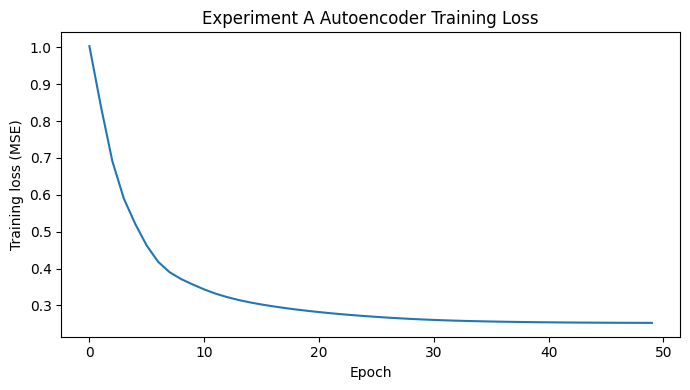

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Keep TensorFlow results reproducible across repeated runs.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# Compress the features to a small bottleneck and reconstruct the original input.
autoencoder = Sequential([
    Input(shape=(len(base_feature_columns),)),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(4, activation="relu"),
    Dense(len(base_feature_columns), activation="linear")
])

# MSE measures the difference between the original and reconstructed features.
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# Train the Autoencoder on the complete prepared dataset.
history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=50,
    batch_size=128,
    shuffle=True,
    verbose=0
)

# Reconstruct the same prepared observations.
reconstructed = autoencoder.predict(X_scaled, verbose=0)

# Reconstruction error is used as the anomaly score.
reconstruction_error = np.mean(
    (X_scaled.values - reconstructed) ** 2,
    axis=1
)

# Use the 95th percentile as the main unsupervised threshold.
# Alternative percentiles are tested later in the sensitivity analysis.
autoencoder_threshold = np.percentile(reconstruction_error, 95)

autoencoder_results = model_df[["cycle", "cell"]].copy()
autoencoder_results["anomaly_score"] = reconstruction_error

autoencoder_results["is_anomalous"] = (
    autoencoder_results["anomaly_score"] > autoencoder_threshold
)

print("Total analysed observations:", len(autoencoder_results))
print("Autoencoder anomaly threshold:", round(autoencoder_threshold, 4))
print("Autoencoder anomalies:", autoencoder_results["is_anomalous"].sum())

display(
    autoencoder_results
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

# Inspect training behaviour only; this is not an accuracy measure.
print("Final training loss:", round(history.history["loss"][-1], 6))

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Training loss (MSE)")
plt.title("Experiment A Autoencoder Training Loss")
plt.tight_layout()
plt.show()

#### Anomaly Persistence

Persistence is calculated across the retained WLTP cycles.


In [13]:
autoencoder_cell_summary = (
    autoencoder_results
    .groupby("cell")
    .agg(
        mean_anomaly_score=("anomaly_score", "mean"),
        max_anomaly_score=("anomaly_score", "max"),
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("is_anomalous", "count")
    )
    .reset_index()
)

autoencoder_cell_summary["anomalous_percentage"] = (
    autoencoder_cell_summary["anomalous_cycles"]
    / autoencoder_cell_summary["total_cycles"]
    * 100
)

display(
    autoencoder_cell_summary
    .sort_values("anomalous_percentage", ascending=False)
    .head(15)
    .round({
        "mean_anomaly_score": 4,
        "max_anomaly_score": 4,
        "anomalous_percentage": 2
    })
)

,cell,mean_anomaly_score,max_anomaly_score,anomalous_cycles,total_cycles,anomalous_percentage
7,P1S6,3.0172,8.2991,216,314,68.79
22,P2S9,0.7301,36.6695,46,314,14.65
21,P2S8,0.3033,10.5566,23,314,7.32
19,P2S6,0.2630,8.5253,15,314,4.78
3,P1S12,0.2779,6.9163,13,314,4.14
25,P3S12,0.1739,8.7324,12,314,3.82
2,P1S11,0.1552,1.9466,12,314,3.82
12,P2S10,0.1440,2.0596,12,314,3.82
10,P1S9,0.1477,1.9100,11,314,3.50
1,P1S10,0.1517,2.3530,11,314,3.50


### Silhouette Score

Silhouette Score describes internal separation between the model-generated groups; it is not accuracy. Comparisons across A/B/C are descriptive because the feature spaces differ.


In [14]:
from sklearn.metrics import silhouette_score

silhouette_results = []

model_labels = {
    "Isolation Forest": isolation_forest_results["is_anomalous"].astype(int),
    "One-Class SVM": ocsvm_results["is_anomalous"].astype(int),
    "Autoencoder": autoencoder_results["is_anomalous"].astype(int)
}

for model_name, labels in model_labels.items():

    score = silhouette_score(X_scaled, labels)

    silhouette_results.append({
        "model": model_name,
        "silhouette_score": score,
        "anomalous_observations": int(labels.sum()),
        "normal_observations": int((labels == 0).sum())
    })

silhouette_summary = (
    pd.DataFrame(silhouette_results)
    .sort_values("silhouette_score", ascending=False)
)

display(silhouette_summary.round(4))

,model,silhouette_score,anomalous_observations,normal_observations
2,Autoencoder,0.6110,534,10142
1,One-Class SVM,0.5296,537,10139
0,Isolation Forest,0.5037,1710,8966


### Consensus Anomalies

Consensus is the intersection of the Isolation Forest, One-Class SVM and Autoencoder decisions. It represents stronger model agreement, not physical fault evidence, and is affected by differences in the models' anomaly rates.


In [15]:
consensus_results = (
    isolation_forest_results[
        ["cycle", "cell", "is_anomalous"]
    ]
    .rename(columns={
        "is_anomalous": "if_anomalous"
    })
    .merge(
        ocsvm_results[
            ["cycle", "cell", "is_anomalous"]
        ].rename(columns={
            "is_anomalous": "ocsvm_anomalous"
        }),
        on=["cycle", "cell"]
    )
    .merge(
        autoencoder_results[
            ["cycle", "cell", "is_anomalous"]
        ].rename(columns={
            "is_anomalous": "ae_anomalous"
        }),
        on=["cycle", "cell"]
    )
)

consensus_results["consensus_anomaly"] = (
    consensus_results["if_anomalous"]
    & consensus_results["ocsvm_anomalous"]
    & consensus_results["ae_anomalous"]
)

print("Total consensus anomalies:", consensus_results["consensus_anomaly"].sum())

display(
    consensus_results[
        consensus_results["consensus_anomaly"]
    ].head(20)
)

Total consensus anomalies: 300


,cycle,cell,if_anomalous,ocsvm_anomalous,ae_anomalous,consensus_anomaly
24,3,P3S10,True,True,True,True
25,3,P3S12,True,True,True,True
33,3,P3S9,True,True,True,True
126,6,P3S10,True,True,True,True
127,6,P3S12,True,True,True,True
135,6,P3S9,True,True,True,True
306,12,P1S1,True,True,True,True
307,12,P1S10,True,True,True,True
310,12,P1S2,True,True,True,True
311,12,P1S3,True,True,True,True


#### Consensus Anomaly Persistence

This counts consensus detections for each cell across retained WLTP cycles.


In [16]:
consensus_cell_summary = (
    consensus_results
    .groupby("cell")
    .agg(
        consensus_anomalous_cycles=("consensus_anomaly", "sum"),
        total_cycles=("cycle", "count")
    )
    .reset_index()
)

consensus_cell_summary["consensus_percentage"] = (
    consensus_cell_summary["consensus_anomalous_cycles"]
    / consensus_cell_summary["total_cycles"]
    * 100
)

display(
    consensus_cell_summary[
        consensus_cell_summary["consensus_anomalous_cycles"] > 0
    ]
    .sort_values("consensus_anomalous_cycles", ascending=False)
    .round(2)
)

,cell,consensus_anomalous_cycles,total_cycles,consensus_percentage
7,P1S6,106,314,33.76
22,P2S9,46,314,14.65
21,P2S8,21,314,6.69
19,P2S6,13,314,4.14
25,P3S12,9,314,2.87
3,P1S12,8,314,2.55
1,P1S10,7,314,2.23
2,P1S11,6,314,1.91
14,P2S12,5,314,1.59
9,P1S8,5,314,1.59


### Experiment A Summary

Experiment A produced 300 consensus observations. P1S6 had the highest consensus persistence (33.76%), followed by P2S9 (14.65%).


## Experiment B: Voltage, Historical and Temperature Features

Experiment B adds three temperature features to Experiment A, giving eight features in total. It uses the same 34 cells and observations.


In [17]:
temperature_feature_records = []

for file_name in retained_wltp_file_names:

    file_path = DATA_DIR / file_name

    df = pd.read_parquet(
        file_path,
        columns=[
            "Semicycle",
            *cell_temperature_columns
        ]
    )

    wltp = df[df["Semicycle"] == "WLTP"].copy()

    if len(wltp) == 0:
        continue

    cycle_number = int(file_name.split("_")[2])

    # Mask implausible temperature readings.
    temperature_data = wltp[cell_temperature_columns].mask(
        (wltp[cell_temperature_columns] < 5)
        | (wltp[cell_temperature_columns] > 80)
    )

    # Average the top and bottom sensors for each reliable cell.
    cell_temperature_data = {}

    for cell in reliable_temperature_cells:
        cell_temperature_data[cell] = temperature_data[
            [
                f"Temperature_Cell_Top_{cell} [degC]",
                f"Temperature_Cell_Bottom_{cell} [degC]"
            ]
        ].mean(axis=1)

    cell_temperature_df = pd.DataFrame(cell_temperature_data)
    pack_temperature_mean = cell_temperature_df.mean(axis=1)

    for cell in reliable_temperature_cells:

        cell_temperature = cell_temperature_df[cell]

        temperature_feature_records.append({
            "cycle": cycle_number,
            "cell": cell,
            "temperature_mean": cell_temperature.mean(),
            "temperature_max": cell_temperature.max(),
            "temperature_deviation": (
                cell_temperature - pack_temperature_mean
            ).abs().mean()
        })

temperature_feature_df = (
    pd.DataFrame(temperature_feature_records)
    .sort_values(["cell", "cycle"])
    .reset_index(drop=True)
)

print("Temperature feature table shape:", temperature_feature_df.shape)
print(
    "Cells with reliable temperature data:",
    temperature_feature_df["cell"].nunique()
)

print("\nMissing values:")
print(
    temperature_feature_df[
        [
            "temperature_mean",
            "temperature_max",
            "temperature_deviation"
        ]
    ].isna().sum()
)

display(
    temperature_feature_df
    .head(10)
    .round(4)
)

Temperature feature table shape: (10710, 5)
Cells with reliable temperature data: 34

Missing values:
temperature_mean         0
temperature_max          0
temperature_deviation    0
dtype: int64


,cycle,cell,temperature_mean,temperature_max,temperature_deviation
0,2,P1S1,24.639299,25.335,2.0626
1,3,P1S1,25.199200,26.235,2.3866
2,4,P1S1,25.062300,26.160,2.4233
3,5,P1S1,28.491501,32.365,2.3077
4,6,P1S1,28.712099,32.335,2.0760
5,7,P1S1,24.798300,26.310,2.3749
6,8,P1S1,25.101101,26.205,2.3603
7,9,P1S1,29.922800,36.085,2.0059
8,10,P1S1,29.954100,34.430,2.3499
9,11,P1S1,25.130600,26.685,2.3263


### Experiment B Dataset



In [18]:
temperature_feature_columns = [
    "temperature_mean",
    "temperature_max",
    "temperature_deviation"
]

# Experiment B = Experiment A features + temperature features.
experiment_b_feature_columns = (
    base_feature_columns + temperature_feature_columns
)

# Keep only the features that belong to Experiment B.
experiment_b_df = (
    base_model_df[
        ["cycle", "cell"] + base_feature_columns
    ]
    .merge(
        temperature_feature_df[
            ["cycle", "cell"] + temperature_feature_columns
        ],
        on=["cycle", "cell"],
        how="inner"
    )
    .sort_values(["cycle", "cell"])
    .reset_index(drop=True)
)

print("Experiment B feature count:", len(experiment_b_feature_columns))
print("Experiment B dataset shape:", experiment_b_df.shape)
print("Number of cells:", experiment_b_df["cell"].nunique())
print("Number of cycles:", experiment_b_df["cycle"].nunique())

print("\nFeatures used:")
for feature in experiment_b_feature_columns:
    print("-", feature)

print("\nMissing values:")
print(
    experiment_b_df[
        experiment_b_feature_columns
    ].isna().sum()
)

display(
    experiment_b_df
    .head(10)
    .round(4)
)

Experiment B feature count: 8
Experiment B dataset shape: (10676, 10)
Number of cells: 34
Number of cycles: 314

Features used:
- voltage_mean
- voltage_min
- voltage_deviation
- lowest_voltage_frequency
- voltage_deviation_change
- temperature_mean
- temperature_max
- temperature_deviation

Missing values:
voltage_mean                0
voltage_min                 0
voltage_deviation           0
lowest_voltage_frequency    0
voltage_deviation_change    0
temperature_mean            0
temperature_max             0
temperature_deviation       0
dtype: int64


,cycle,cell,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency,voltage_deviation_change,temperature_mean,temperature_max,temperature_deviation
0,3,P1S1,3.9796,3.504,0.0550,0.0000,0.0398,25.199200,26.235,2.3866
1,3,P1S10,3.9794,3.538,0.0603,13.8921,0.0444,28.741600,31.865,1.1557
2,3,P1S11,3.9803,3.554,0.0583,0.0000,0.0424,28.358999,31.440,0.7806
3,3,P1S12,3.9808,3.560,0.0583,4.1531,0.0394,28.037001,30.170,0.4584
4,3,P1S2,3.9791,3.504,0.0545,0.3611,0.0403,26.709801,30.010,0.8951
5,3,P1S3,3.9794,3.495,0.0564,0.0379,0.0420,26.976200,29.180,0.6431
6,3,P1S4,3.9767,3.493,0.0568,14.7600,0.0418,26.461599,28.500,1.1258
7,3,P1S6,3.9826,3.469,0.0616,0.6961,0.0451,25.187799,27.125,2.3980
8,3,P1S7,3.9849,3.494,0.0566,0.0000,0.0416,25.820400,26.940,1.7654
9,3,P1S8,3.9842,3.495,0.0568,5.1346,0.0418,27.444000,29.100,0.2281


### Full Dataset Scaling

The full Experiment B dataset is standardised before unsupervised modelling.

In [19]:
from sklearn.preprocessing import StandardScaler

# Use the complete Experiment B dataset.
experiment_b_model_df = (
    experiment_b_df
    .sort_values(["cycle", "cell"])
    .reset_index(drop=True)
    .copy()
)

X_b = experiment_b_model_df[
    experiment_b_feature_columns
].copy()

experiment_b_scaler = StandardScaler()

X_scaled_b = pd.DataFrame(
    experiment_b_scaler.fit_transform(X_b),
    columns=experiment_b_feature_columns,
    index=experiment_b_model_df.index
)

print("Experiment B observations:", len(experiment_b_model_df))
print("Experiment B cells:", experiment_b_model_df["cell"].nunique())
print("Experiment B cycles:", experiment_b_model_df["cycle"].nunique())
print("Scaled feature shape:", X_scaled_b.shape)

display(X_scaled_b.head().round(3))

Experiment B observations: 10676
Experiment B cells: 34
Experiment B cycles: 314
Scaled feature shape: (10676, 8)


,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency,voltage_deviation_change,temperature_mean,temperature_max,temperature_deviation
0,0.806,0.844,1.940,-0.244,2.687,-1.736,-1.768,3.509
1,0.805,0.942,2.213,0.910,3.002,0.378,0.677,0.932
2,0.811,0.988,2.110,-0.244,2.866,0.150,0.492,0.147
3,0.815,1.005,2.109,0.101,2.660,-0.043,-0.059,-0.527
4,0.803,0.844,1.916,-0.214,2.720,-0.834,-0.129,0.387


### Isolation Forest

The Experiment A settings are retained.


In [20]:
from sklearn.ensemble import IsolationForest

isolation_forest_b = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

# Fit the model on the complete Experiment B dataset.
isolation_forest_b.fit(X_scaled_b)

# Higher scores indicate more unusual observations.
if_scores_b = -isolation_forest_b.score_samples(X_scaled_b)

if_results_b = experiment_b_model_df[["cycle", "cell"]].copy()
if_results_b["anomaly_score"] = if_scores_b

# Model-generated anomaly decision.
if_results_b["is_anomalous"] = (
    isolation_forest_b.predict(X_scaled_b) == -1
)

print("Total analysed observations:", len(if_results_b))
print("Isolation Forest anomalies:", if_results_b["is_anomalous"].sum())

display(
    if_results_b
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

Total analysed observations: 10676
Isolation Forest anomalies: 1613


,cycle,cell,anomaly_score,is_anomalous
6705,258,P1S6,0.6947,True
10173,392,P1S6,0.6929,True
10649,410,P1S6,0.6924,True
313,12,P1S6,0.6915,True
10343,397,P1S6,0.6910,True
6569,254,P1S6,0.6908,True
10241,394,P1S6,0.6888,True
10377,398,P1S6,0.6872,True
770,32,P2S9,0.6868,True
10513,404,P1S6,0.6864,True


#### Anomaly Persistence


In [21]:
if_persistence_b = (
    if_results_b
    .groupby("cell")
    .agg(
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("cycle", "count"),
        mean_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

if_persistence_b["anomaly_percentage"] = (
    if_persistence_b["anomalous_cycles"]
    / if_persistence_b["total_cycles"]
    * 100
)

display(
    if_persistence_b
    .sort_values(
        ["anomalous_cycles", "mean_anomaly_score"],
        ascending=False
    )
    .head(10)
    .round(4)
)

,cell,anomalous_cycles,total_cycles,mean_anomaly_score,anomaly_percentage
7,P1S6,280,314,0.5922,89.1720
0,P1S1,93,314,0.4743,29.6178
22,P2S9,83,314,0.4340,26.4331
8,P1S7,72,314,0.4653,22.9299
21,P2S8,62,314,0.4202,19.7452
6,P1S4,55,314,0.4250,17.5159
19,P2S6,47,314,0.4397,14.9682
28,P3S4,47,314,0.4228,14.9682
30,P3S6,45,314,0.4215,14.3312
17,P2S4,43,314,0.4363,13.6943


### One-Class SVM

The Experiment A settings are retained.


In [22]:
from sklearn.svm import OneClassSVM

one_class_svm_b = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

# Fit the model on the complete Experiment B dataset.
one_class_svm_b.fit(X_scaled_b)

# Higher scores indicate more unusual observations.
ocsvm_scores_b = -one_class_svm_b.decision_function(X_scaled_b)

ocsvm_results_b = experiment_b_model_df[["cycle", "cell"]].copy()
ocsvm_results_b["anomaly_score"] = ocsvm_scores_b

# Model-generated anomaly decision.
ocsvm_results_b["is_anomalous"] = (
    one_class_svm_b.predict(X_scaled_b) == -1
)

print("Total analysed observations:", len(ocsvm_results_b))
print("One-Class SVM anomalies:", ocsvm_results_b["is_anomalous"].sum())

display(
    ocsvm_results_b
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

Total analysed observations: 10676
One-Class SVM anomalies: 534


,cycle,cell,anomaly_score,is_anomalous
2164,84,P2S9,27.1548,True
2198,85,P2S9,27.1519,True
600,25,P2S9,25.5011,True
838,34,P2S9,24.8248,True
498,21,P2S9,23.7817,True
362,16,P2S9,23.1988,True
872,35,P2S9,22.5893,True
2333,90,P2S8,22.5113,True
1722,68,P2S9,22.3799,True
3048,113,P2S9,21.9963,True


#### Anomaly Persistence


In [23]:
ocsvm_persistence_b = (
    ocsvm_results_b
    .groupby("cell")
    .agg(
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("cycle", "count"),
        mean_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

ocsvm_persistence_b["anomaly_percentage"] = (
    ocsvm_persistence_b["anomalous_cycles"]
    / ocsvm_persistence_b["total_cycles"]
    * 100
)

display(
    ocsvm_persistence_b
    .sort_values(
        ["anomalous_cycles", "mean_anomaly_score"],
        ascending=False
    )
    .head(10)
    .round(4)
)

,cell,anomalous_cycles,total_cycles,mean_anomaly_score,anomaly_percentage
7,P1S6,97,314,-1.6664,30.8917
22,P2S9,56,314,-3.7910,17.8344
0,P1S1,47,314,-2.3374,14.9682
8,P1S7,28,314,-2.8000,8.9172
21,P2S8,25,314,-2.4111,7.9618
19,P2S6,19,314,-6.3440,6.0510
23,P3S1,15,314,-3.2761,4.7771
25,P3S12,15,314,-4.9312,4.7771
15,P2S2,14,314,-3.0865,4.4586
3,P1S12,14,314,-3.6103,4.4586


### Autoencoder

The Experiment A architecture and training settings are retained. The anomaly threshold is the 95th percentile of Experiment B reconstruction error.


Total analysed observations: 10676
Autoencoder anomaly threshold: 1.6461
Autoencoder anomalies: 534


,cycle,cell,anomaly_score,is_anomalous
2164,84,P2S9,29.6009,True
2198,85,P2S9,25.6415,True
600,25,P2S9,12.9858,True
838,34,P2S9,10.1405,True
10343,397,P1S6,9.9179,True
498,21,P2S9,9.3499,True
6705,258,P1S6,9.0103,True
10173,392,P1S6,8.8309,True
1722,68,P2S9,8.7184,True
6569,254,P1S6,8.6555,True


Final training loss: 0.467757


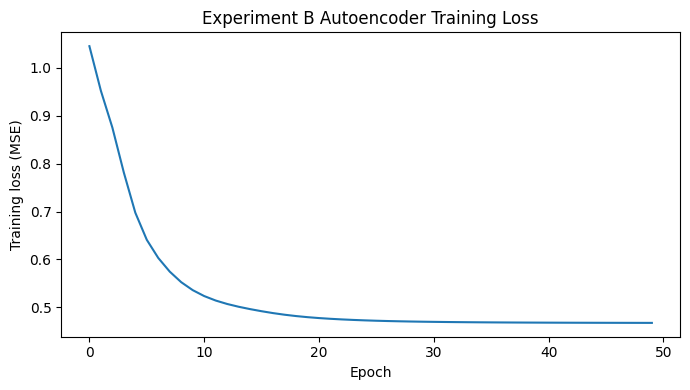

In [24]:
import tensorflow as tf
import numpy as np

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

autoencoder_b = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(experiment_b_feature_columns),)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(2, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(
        len(experiment_b_feature_columns),
        activation="linear"
    )
])

autoencoder_b.compile(
    optimizer="adam",
    loss="mse"
)

# Train on the complete Experiment B dataset.
history_b = autoencoder_b.fit(
    X_scaled_b,
    X_scaled_b,
    epochs=50,
    batch_size=128,
    shuffle=True,
    verbose=0
)

# Reconstruct the complete Experiment B dataset.
predictions_b = autoencoder_b.predict(X_scaled_b, verbose=0)

# Reconstruction error is used as the anomaly score.
reconstruction_error_b = np.mean(
    (X_scaled_b.values - predictions_b) ** 2,
    axis=1
)

# Threshold = 95th percentile of reconstruction errors.
autoencoder_threshold_b = np.percentile(reconstruction_error_b, 95)

autoencoder_results_b = experiment_b_model_df[["cycle", "cell"]].copy()
autoencoder_results_b["anomaly_score"] = reconstruction_error_b

autoencoder_results_b["is_anomalous"] = (
    autoencoder_results_b["anomaly_score"] > autoencoder_threshold_b
)

print("Total analysed observations:", len(autoencoder_results_b))
print("Autoencoder anomaly threshold:", round(autoencoder_threshold_b, 4))
print("Autoencoder anomalies:", autoencoder_results_b["is_anomalous"].sum())

display(
    autoencoder_results_b
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

# Inspect training behaviour only; this is not an accuracy measure.
print("Final training loss:", round(history_b.history["loss"][-1], 6))

plt.figure(figsize=(7, 4))
plt.plot(history_b.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Training loss (MSE)")
plt.title("Experiment B Autoencoder Training Loss")
plt.tight_layout()
plt.show()

#### Anomaly Persistence


In [25]:
autoencoder_persistence_b = (
    autoencoder_results_b
    .groupby("cell")
    .agg(
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("cycle", "count"),
        mean_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

autoencoder_persistence_b["anomaly_percentage"] = (
    autoencoder_persistence_b["anomalous_cycles"]
    / autoencoder_persistence_b["total_cycles"]
    * 100
)

display(
    autoencoder_persistence_b
    .sort_values(
        ["anomalous_cycles", "mean_anomaly_score"],
        ascending=False
    )
    .head(10)
    .round(4)
)

,cell,anomalous_cycles,total_cycles,mean_anomaly_score,anomaly_percentage
7,P1S6,220,314,4.0575,70.0637
22,P2S9,47,314,0.9644,14.9682
21,P2S8,26,314,0.5367,8.2803
0,P1S1,21,314,0.7654,6.6879
19,P2S6,16,314,0.3870,5.0955
8,P1S7,15,314,0.6733,4.7771
3,P1S12,11,314,0.3844,3.5032
23,P3S1,11,314,0.3451,3.5032
25,P3S12,10,314,0.3345,3.1847
30,P3S6,9,314,0.3444,2.8662


### Silhouette Score

Silhouette Score describes internal separation, not accuracy. Comparisons with A and C are descriptive because their feature spaces differ.


In [26]:
from sklearn.metrics import silhouette_score

silhouette_results_b = []

model_labels_b = {
    "Isolation Forest": if_results_b["is_anomalous"].astype(int),
    "One-Class SVM": ocsvm_results_b["is_anomalous"].astype(int),
    "Autoencoder": autoencoder_results_b["is_anomalous"].astype(int)
}

for model_name, labels in model_labels_b.items():

    score = silhouette_score(X_scaled_b, labels)

    silhouette_results_b.append({
        "model": model_name,
        "silhouette_score": score,
        "anomalous_observations": int(labels.sum()),
        "normal_observations": int((labels == 0).sum())
    })

silhouette_summary_b = (
    pd.DataFrame(silhouette_results_b)
    .sort_values("silhouette_score", ascending=False)
)

display(silhouette_summary_b.round(4))

,model,silhouette_score,anomalous_observations,normal_observations
2,Autoencoder,0.5007,534,10142
1,One-Class SVM,0.4308,534,10142
0,Isolation Forest,0.4018,1613,9063


### Consensus Anomalies

Consensus requires agreement from all three models. It identifies stronger unusual-behaviour candidates, not physical faults.


In [27]:
consensus_results_b = (
    if_results_b[
        ["cycle", "cell", "is_anomalous"]
    ]
    .rename(columns={
        "is_anomalous": "if_anomalous"
    })
    .merge(
        ocsvm_results_b[
            ["cycle", "cell", "is_anomalous"]
        ].rename(columns={
            "is_anomalous": "ocsvm_anomalous"
        }),
        on=["cycle", "cell"]
    )
    .merge(
        autoencoder_results_b[
            ["cycle", "cell", "is_anomalous"]
        ].rename(columns={
            "is_anomalous": "ae_anomalous"
        }),
        on=["cycle", "cell"]
    )
)

consensus_results_b["consensus_anomaly"] = (
    consensus_results_b["if_anomalous"]
    & consensus_results_b["ocsvm_anomalous"]
    & consensus_results_b["ae_anomalous"]
)

print("Total consensus anomalies:", consensus_results_b["consensus_anomaly"].sum())

display(
    consensus_results_b[
        consensus_results_b["consensus_anomaly"]
    ].head(20)
)

Total consensus anomalies: 275


,cycle,cell,if_anomalous,ocsvm_anomalous,ae_anomalous,consensus_anomaly
0,3,P1S1,True,True,True,True
7,3,P1S6,True,True,True,True
24,3,P3S10,True,True,True,True
25,3,P3S12,True,True,True,True
33,3,P3S9,True,True,True,True
41,4,P1S6,True,True,True,True
76,5,P1S7,True,True,True,True
91,5,P3S1,True,True,True,True
96,5,P3S4,True,True,True,True
126,6,P3S10,True,True,True,True


#### Consensus Anomaly Persistence


In [28]:
consensus_cell_summary_b = (
    consensus_results_b
    .groupby("cell")
    .agg(
        consensus_anomalous_cycles=("consensus_anomaly", "sum"),
        total_cycles=("cycle", "count")
    )
    .reset_index()
)

consensus_cell_summary_b["consensus_percentage"] = (
    consensus_cell_summary_b["consensus_anomalous_cycles"]
    / consensus_cell_summary_b["total_cycles"]
    * 100
)

display(
    consensus_cell_summary_b[
        consensus_cell_summary_b["consensus_anomalous_cycles"] > 0
    ]
    .sort_values("consensus_anomalous_cycles", ascending=False)
    .round(2)
)

,cell,consensus_anomalous_cycles,total_cycles,consensus_percentage
7,P1S6,84,314,26.75
22,P2S9,45,314,14.33
0,P1S1,19,314,6.05
21,P2S8,14,314,4.46
19,P2S6,13,314,4.14
8,P1S7,9,314,2.87
30,P3S6,7,314,2.23
25,P3S12,7,314,2.23
18,P2S5,5,314,1.59
2,P1S11,5,314,1.59


### Experiment B Summary

Experiment B produced 275 consensus observations. P1S6 remained the leading persistent anomaly candidate (26.75%), followed by P2S9 (14.33%).


## Experiment C: Voltage, Historical, Temperature and Operating-Condition Features

Experiment C adds four operating-context features to Experiment B, giving 12 features. It uses the same 34 cells and observations.


In [29]:
operating_feature_records = []

for file_name in retained_wltp_file_names:

    file_path = DATA_DIR / file_name

    df = pd.read_parquet(
        file_path,
        columns=[
            "Semicycle",
            "Current_Actual_Battery [A]",
            "SoC_Actual_Battery [percent]",
            *cell_voltage_columns
        ]
    )

    wltp = df[df["Semicycle"] == "WLTP"].copy()

    if len(wltp) == 0:
        continue

    cycle_number = int(file_name.split("_")[2])

    # Pack-average cell voltage at each timestamp.
    pack_voltage_mean = wltp[cell_voltage_columns].mean(axis=1)

    # Absolute current represents load intensity rather than current direction.
    absolute_current = wltp["Current_Actual_Battery [A]"].abs()

    # Within-cycle quartiles define relative operating regions, not physical thresholds.
    low_load_threshold = absolute_current.quantile(0.25)
    high_load_threshold = absolute_current.quantile(0.75)

    low_load_mask = absolute_current <= low_load_threshold
    high_load_mask = absolute_current >= high_load_threshold

    soc = wltp["SoC_Actual_Battery [percent]"]

    low_soc_threshold = soc.quantile(0.25)
    high_soc_threshold = soc.quantile(0.75)

    low_soc_mask = soc <= low_soc_threshold
    high_soc_mask = soc >= high_soc_threshold

    for cell in reliable_temperature_cells:

        voltage_column = f"Voltage_Cell_{cell} [V]"

        voltage_deviation = (
            wltp[voltage_column] - pack_voltage_mean
        ).abs()

        high_load_deviation = voltage_deviation[high_load_mask].mean()
        low_load_deviation = voltage_deviation[low_load_mask].mean()

        low_soc_deviation = voltage_deviation[low_soc_mask].mean()
        high_soc_deviation = voltage_deviation[high_soc_mask].mean()

        operating_feature_records.append({
            "cycle": cycle_number,
            "cell": cell,
            "high_load_voltage_deviation": high_load_deviation,
            "load_response_difference": high_load_deviation - low_load_deviation,
            "low_soc_voltage_deviation": low_soc_deviation,
            "soc_response_difference": low_soc_deviation - high_soc_deviation
        })

operating_feature_df = (
    pd.DataFrame(operating_feature_records)
    .sort_values(["cell", "cycle"])
    .reset_index(drop=True)
)

operating_feature_columns = [
    "high_load_voltage_deviation",
    "load_response_difference",
    "low_soc_voltage_deviation",
    "soc_response_difference"
]

print("Operating-condition feature table shape:", operating_feature_df.shape)
print("Number of cells:", operating_feature_df["cell"].nunique())
print("Number of cycles:", operating_feature_df["cycle"].nunique())
print("Number of operating-condition features:", len(operating_feature_columns))

print("\nFeatures used:")
for feature in operating_feature_columns:
    print("-", feature)

print("\nMissing values:")
print(
    operating_feature_df[
        operating_feature_columns
    ].isna().sum()
)

display(
    operating_feature_df
    .head(10)
    .round(5)
)

Operating-condition feature table shape: (10710, 6)
Number of cells: 34
Number of cycles: 315
Number of operating-condition features: 4

Features used:
- high_load_voltage_deviation
- load_response_difference
- low_soc_voltage_deviation
- soc_response_difference

Missing values:
high_load_voltage_deviation    0
load_response_difference       0
low_soc_voltage_deviation      0
soc_response_difference        0
dtype: int64


,cycle,cell,high_load_voltage_deviation,load_response_difference,low_soc_voltage_deviation,soc_response_difference
0,2,P1S1,0.03084,0.02642,0.01520,0.00092
1,3,P1S1,0.08482,0.03941,0.08913,0.07388
2,4,P1S1,0.08784,0.04138,0.06576,0.05625
3,5,P1S1,0.06967,0.02302,0.04007,0.02836
4,6,P1S1,0.05142,0.01931,0.05627,0.04962
5,7,P1S1,0.05184,0.02411,0.05599,0.04877
6,8,P1S1,0.05724,0.00721,0.06747,0.06482
7,9,P1S1,0.06748,0.03678,0.04852,0.03555
8,10,P1S1,0.07608,0.04910,0.06665,0.05855
9,11,P1S1,0.05139,0.02559,0.05314,0.04759


### Operating-Condition Features

Absolute current and SoC define relative operating context rather than direct cell-specific features. High/low load and lower/higher SoC use within-cycle quartiles, not fixed physical thresholds.


In [30]:
# Experiment B already contains only history-ready observations because the temporal feature needs a previous cycle.
experiment_c_df = (
    experiment_b_model_df
    .merge(
        operating_feature_df,
        on=["cycle", "cell"],
        how="inner"
    )
    .sort_values(["cycle", "cell"])
    .reset_index(drop=True)
)

experiment_c_feature_columns = (
    experiment_b_feature_columns
    + operating_feature_columns
)

print("Experiment C dataset shape:", experiment_c_df.shape)
print("Experiment C observations:", len(experiment_c_df))
print("Experiment C cells:", experiment_c_df["cell"].nunique())
print("Experiment C cycles:", experiment_c_df["cycle"].nunique())
print("Number of Experiment C features:", len(experiment_c_feature_columns))

print("\nMissing feature values:")
print(
    experiment_c_df[
        experiment_c_feature_columns
    ].isna().sum()
)

# Check that A, B and C use identical cell-cycle observations for a controlled comparison.
experiment_a_keys = set(
    map(tuple, model_df[["cycle", "cell"]].to_numpy())
)

experiment_b_keys = set(
    map(tuple, experiment_b_model_df[["cycle", "cell"]].to_numpy())
)

experiment_c_keys = set(
    map(tuple, experiment_c_df[["cycle", "cell"]].to_numpy())
)

if not (experiment_a_keys == experiment_b_keys == experiment_c_keys):
    raise ValueError(
        "A/B/C observation mismatch. Check missing feature rows before modelling."
    )

print("A/B/C observation identity check: Passed")
print("Common observations:", len(experiment_a_keys))

Experiment C dataset shape: (10676, 14)
Experiment C observations: 10676
Experiment C cells: 34
Experiment C cycles: 314
Number of Experiment C features: 12

Missing feature values:
voltage_mean                   0
voltage_min                    0
voltage_deviation              0
lowest_voltage_frequency       0
voltage_deviation_change       0
temperature_mean               0
temperature_max                0
temperature_deviation          0
high_load_voltage_deviation    0
load_response_difference       0
low_soc_voltage_deviation      0
soc_response_difference        0
dtype: int64
A/B/C observation identity check: Passed
Common observations: 10676


### Full Dataset Scaling

The full Experiment C dataset is standardised. Its cycle-cell observations are checked against Experiments A and B.


In [31]:
from sklearn.preprocessing import StandardScaler

X_c = experiment_c_df[
    experiment_c_feature_columns
].copy()

# Standardise the complete prepared Experiment C dataset before unsupervised modelling.
experiment_c_scaler = StandardScaler()

X_scaled_c = pd.DataFrame(
    experiment_c_scaler.fit_transform(X_c),
    columns=experiment_c_feature_columns,
    index=experiment_c_df.index
)

print("Original feature shape:", X_c.shape)
print("Scaled feature shape:", X_scaled_c.shape)

display(
    X_scaled_c
    .head()
    .round(3)
)

Original feature shape: (10676, 12)
Scaled feature shape: (10676, 12)


,voltage_mean,voltage_min,voltage_deviation,lowest_voltage_frequency,voltage_deviation_change,temperature_mean,temperature_max,temperature_deviation,high_load_voltage_deviation,load_response_difference,low_soc_voltage_deviation,soc_response_difference
0,0.806,0.844,1.940,-0.244,2.687,-1.736,-1.768,3.509,1.609,0.870,2.298,2.268
1,0.805,0.942,2.213,0.910,3.002,0.378,0.677,0.932,1.809,0.948,2.649,2.732
2,0.811,0.988,2.110,-0.244,2.866,0.150,0.492,0.147,1.720,0.872,2.455,2.424
3,0.815,1.005,2.109,0.101,2.660,-0.043,-0.059,-0.527,1.717,0.880,2.311,2.171
4,0.803,0.844,1.916,-0.214,2.720,-0.834,-0.129,0.387,1.604,0.887,2.298,2.302


### Isolation Forest

The same main settings are used as in Experiments A and B.


In [32]:
from sklearn.ensemble import IsolationForest

isolation_forest_c = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

# Fit using all prepared Experiment C observations.
isolation_forest_c.fit(X_scaled_c)

# Higher scores represent more unusual observations.
if_scores_c = -isolation_forest_c.score_samples(X_scaled_c)

if_results_c = experiment_c_df[["cycle", "cell"]].copy()
if_results_c["anomaly_score"] = if_scores_c

if_results_c["is_anomalous"] = (
    isolation_forest_c.predict(X_scaled_c) == -1
)

print("Total analysed observations:", len(if_results_c))
print("Isolation Forest anomalies:", if_results_c["is_anomalous"].sum())

display(
    if_results_c
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

Total analysed observations: 10676
Isolation Forest anomalies: 1634


,cycle,cell,anomaly_score,is_anomalous
2164,84,P2S9,0.7234,True
2469,94,P2S8,0.7217,True
10377,398,P1S6,0.7131,True
636,28,P3S10,0.7115,True
10343,397,P1S6,0.7100,True
10173,392,P1S6,0.7100,True
637,28,P3S12,0.7062,True
770,32,P2S9,0.7027,True
10649,410,P1S6,0.6990,True
10513,404,P1S6,0.6974,True


#### Anomaly Persistence


In [33]:
if_persistence_c = (
    if_results_c
    .groupby("cell")
    .agg(
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("cycle", "count"),
        mean_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

if_persistence_c["anomaly_percentage"] = (
    if_persistence_c["anomalous_cycles"]
    / if_persistence_c["total_cycles"]
    * 100
)

display(
    if_persistence_c
    .sort_values(
        ["anomalous_cycles", "mean_anomaly_score"],
        ascending=False
    )
    .head(10)
    .round(4)
)

,cell,anomalous_cycles,total_cycles,mean_anomaly_score,anomaly_percentage
7,P1S6,272,314,0.5878,86.6242
0,P1S1,80,314,0.4537,25.4777
22,P2S9,80,314,0.4274,25.4777
21,P2S8,68,314,0.4254,21.6561
8,P1S7,61,314,0.4477,19.4268
25,P3S12,52,314,0.4193,16.5605
19,P2S6,49,314,0.4504,15.6051
2,P1S11,49,314,0.4125,15.6051
23,P3S1,48,314,0.4304,15.2866
6,P1S4,48,314,0.4231,15.2866


### One-Class SVM

The same main settings are used as in Experiments A and B.


In [34]:
from sklearn.svm import OneClassSVM

one_class_svm_c = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

# Use the complete prepared dataset for unsupervised fitting.
one_class_svm_c.fit(X_scaled_c)

# Keep larger scores associated with more unusual observations.
ocsvm_scores_c = -one_class_svm_c.decision_function(X_scaled_c)

ocsvm_results_c = experiment_c_df[["cycle", "cell"]].copy()
ocsvm_results_c["anomaly_score"] = ocsvm_scores_c

ocsvm_results_c["is_anomalous"] = (
    one_class_svm_c.predict(X_scaled_c) == -1
)

print("Total analysed observations:", len(ocsvm_results_c))
print("One-Class SVM anomalies:", ocsvm_results_c["is_anomalous"].sum())

display(
    ocsvm_results_c
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

Total analysed observations: 10676
One-Class SVM anomalies: 532


,cycle,cell,anomaly_score,is_anomalous
2164,84,P2S9,27.5439,True
2198,85,P2S9,27.5367,True
2469,94,P2S8,26.4020,True
636,28,P3S10,25.3073,True
637,28,P3S12,24.7782,True
600,25,P2S9,24.7669,True
645,28,P3S9,24.6662,True
872,35,P2S9,24.6294,True
804,33,P2S9,23.7642,True
838,34,P2S9,23.1482,True


#### Anomaly Persistence


In [35]:
ocsvm_persistence_c = (
    ocsvm_results_c
    .groupby("cell")
    .agg(
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("cycle", "count"),
        mean_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

ocsvm_persistence_c["anomaly_percentage"] = (
    ocsvm_persistence_c["anomalous_cycles"]
    / ocsvm_persistence_c["total_cycles"]
    * 100
)

display(
    ocsvm_persistence_c
    .sort_values(
        ["anomalous_cycles", "mean_anomaly_score"],
        ascending=False
    )
    .head(10)
    .round(4)
)

,cell,anomalous_cycles,total_cycles,mean_anomaly_score,anomaly_percentage
7,P1S6,104,314,-1.0107,33.1210
22,P2S9,57,314,-4.2557,18.1529
0,P1S1,43,314,-2.6526,13.6943
21,P2S8,30,314,-2.4496,9.5541
8,P1S7,27,314,-2.9406,8.5987
19,P2S6,20,314,-7.3097,6.3694
23,P3S1,15,314,-4.3225,4.7771
13,P2S11,15,314,-5.9738,4.7771
15,P2S2,13,314,-3.8209,4.1401
2,P1S11,12,314,-4.1591,3.8217


### Autoencoder

The same architecture and training settings are retained. The anomaly threshold is the 95th percentile of Experiment C reconstruction error.


Total analysed observations: 10676
Autoencoder anomaly threshold: 1.2245
Autoencoder anomalies: 534


,cycle,cell,anomaly_score,is_anomalous
2164,84,P2S9,25.8997,True
2198,85,P2S9,17.6916,True
600,25,P2S9,9.2692,True
10173,392,P1S6,7.2237,True
838,34,P2S9,6.9781,True
10207,393,P1S6,6.8980,True
10343,397,P1S6,6.8568,True
498,21,P2S9,6.7630,True
6603,255,P1S6,6.6954,True
10139,389,P1S6,6.6274,True


Final training loss: 0.379077


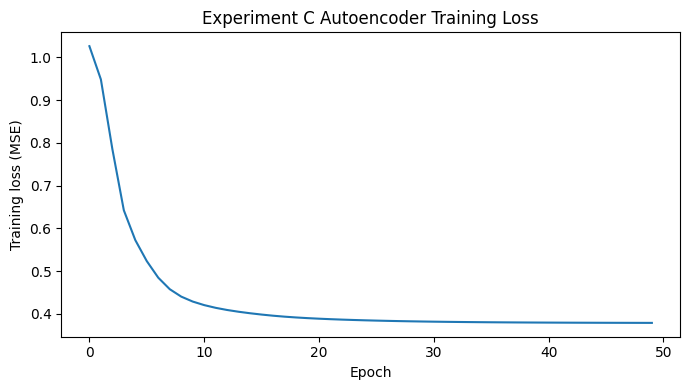

In [36]:
import tensorflow as tf
import numpy as np

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

autoencoder_c = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(experiment_c_feature_columns),)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(2, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(
        len(experiment_c_feature_columns),
        activation="linear"
    )
])

autoencoder_c.compile(
    optimizer="adam",
    loss="mse"
)

# Train on the full prepared unlabeled Experiment C dataset.
history_c = autoencoder_c.fit(
    X_scaled_c,
    X_scaled_c,
    epochs=50,
    batch_size=128,
    shuffle=True,
    verbose=0
)

# The same observations are reconstructed after training.
predictions_c = autoencoder_c.predict(X_scaled_c, verbose=0)

# Mean reconstruction error is used as the anomaly score.
reconstruction_error_c = np.mean(
    (X_scaled_c.values - predictions_c) ** 2,
    axis=1
)

# Use the 95th percentile of reconstruction errors as the threshold.
autoencoder_threshold_c = np.percentile(reconstruction_error_c, 95)

autoencoder_results_c = experiment_c_df[["cycle", "cell"]].copy()
autoencoder_results_c["anomaly_score"] = reconstruction_error_c

autoencoder_results_c["is_anomalous"] = (
    autoencoder_results_c["anomaly_score"] > autoencoder_threshold_c
)

print("Total analysed observations:", len(autoencoder_results_c))
print("Autoencoder anomaly threshold:", round(autoencoder_threshold_c, 4))
print("Autoencoder anomalies:", autoencoder_results_c["is_anomalous"].sum())

display(
    autoencoder_results_c
    .sort_values("anomaly_score", ascending=False)
    .head(15)
    .round(4)
)

# Inspect training behaviour only; this is not an accuracy measure.
print("Final training loss:", round(history_c.history["loss"][-1], 6))

plt.figure(figsize=(7, 4))
plt.plot(history_c.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Training loss (MSE)")
plt.title("Experiment C Autoencoder Training Loss")
plt.tight_layout()
plt.show()

#### Anomaly Persistence


In [37]:
autoencoder_persistence_c = (
    autoencoder_results_c
    .groupby("cell")
    .agg(
        anomalous_cycles=("is_anomalous", "sum"),
        total_cycles=("cycle", "count"),
        mean_anomaly_score=("anomaly_score", "mean")
    )
    .reset_index()
)

autoencoder_persistence_c["anomaly_percentage"] = (
    autoencoder_persistence_c["anomalous_cycles"]
    / autoencoder_persistence_c["total_cycles"]
    * 100
)

display(
    autoencoder_persistence_c
    .sort_values(
        ["anomalous_cycles", "mean_anomaly_score"],
        ascending=False
    )
    .head(10)
    .round(4)
)

,cell,anomalous_cycles,total_cycles,mean_anomaly_score,anomaly_percentage
7,P1S6,223,314,2.7716,71.0191
22,P2S9,37,314,0.6350,11.7834
21,P2S8,20,314,0.3796,6.3694
0,P1S1,17,314,0.6211,5.4140
19,P2S6,16,314,0.3497,5.0955
30,P3S6,14,314,0.2955,4.4586
28,P3S4,13,314,0.2462,4.1401
26,P3S2,12,314,0.2631,3.8217
8,P1S7,11,314,0.5535,3.5032
3,P1S12,11,314,0.3318,3.5032


### Silhouette Score

Silhouette Score describes internal separation, not accuracy. Comparisons with A and B are descriptive because their feature spaces differ.


In [38]:
from sklearn.metrics import silhouette_score

silhouette_results_c = []

model_labels_c = {
    "Isolation Forest": if_results_c["is_anomalous"].astype(int),
    "One-Class SVM": ocsvm_results_c["is_anomalous"].astype(int),
    "Autoencoder": autoencoder_results_c["is_anomalous"].astype(int)
}

for model_name, labels in model_labels_c.items():

    score = silhouette_score(X_scaled_c, labels)

    silhouette_results_c.append({
        "model": model_name,
        "silhouette_score": score,
        "anomalous_observations": int(labels.sum()),
        "normal_observations": int((labels == 0).sum())
    })

silhouette_summary_c = (
    pd.DataFrame(silhouette_results_c)
    .sort_values("silhouette_score", ascending=False)
)

display(silhouette_summary_c.round(4))

,model,silhouette_score,anomalous_observations,normal_observations
2,Autoencoder,0.4925,534,10142
1,One-Class SVM,0.4422,532,10144
0,Isolation Forest,0.4147,1634,9042


### Consensus Anomalies

Consensus requires agreement from all three models. It identifies stronger unusual-behaviour candidates, not physical faults.


In [39]:
consensus_results_c = (
    if_results_c[
        ["cycle", "cell", "is_anomalous"]
    ]
    .rename(columns={
        "is_anomalous": "if_anomalous"
    })
    .merge(
        ocsvm_results_c[
            ["cycle", "cell", "is_anomalous"]
        ].rename(columns={
            "is_anomalous": "ocsvm_anomalous"
        }),
        on=["cycle", "cell"]
    )
    .merge(
        autoencoder_results_c[
            ["cycle", "cell", "is_anomalous"]
        ].rename(columns={
            "is_anomalous": "ae_anomalous"
        }),
        on=["cycle", "cell"]
    )
)

consensus_results_c["consensus_anomaly"] = (
    consensus_results_c["if_anomalous"]
    & consensus_results_c["ocsvm_anomalous"]
    & consensus_results_c["ae_anomalous"]
)

print("Total consensus anomalies:", consensus_results_c["consensus_anomaly"].sum())

display(
    consensus_results_c[
        consensus_results_c["consensus_anomaly"]
    ].head(20)
)

Total consensus anomalies: 297


,cycle,cell,if_anomalous,ocsvm_anomalous,ae_anomalous,consensus_anomaly
0,3,P1S1,True,True,True,True
7,3,P1S6,True,True,True,True
24,3,P3S10,True,True,True,True
25,3,P3S12,True,True,True,True
33,3,P3S9,True,True,True,True
41,4,P1S6,True,True,True,True
76,5,P1S7,True,True,True,True
92,5,P3S10,True,True,True,True
93,5,P3S12,True,True,True,True
96,5,P3S4,True,True,True,True


#### Consensus Anomaly Persistence


In [40]:
consensus_cell_summary_c = (
    consensus_results_c
    .groupby("cell")
    .agg(
        consensus_anomalous_cycles=("consensus_anomaly", "sum"),
        total_cycles=("cycle", "count")
    )
    .reset_index()
)

consensus_cell_summary_c["consensus_percentage"] = (
    consensus_cell_summary_c["consensus_anomalous_cycles"]
    / consensus_cell_summary_c["total_cycles"]
    * 100
)

display(
    consensus_cell_summary_c[
        consensus_cell_summary_c["consensus_anomalous_cycles"] > 0
    ]
    .sort_values("consensus_anomalous_cycles", ascending=False)
    .round(2)
)

,cell,consensus_anomalous_cycles,total_cycles,consensus_percentage
7,P1S6,94,314,29.94
22,P2S9,37,314,11.78
0,P1S1,17,314,5.41
21,P2S8,16,314,5.10
19,P2S6,13,314,4.14
8,P1S7,9,314,2.87
28,P3S4,8,314,2.55
30,P3S6,8,314,2.55
24,P3S10,7,314,2.23
26,P3S2,7,314,2.23


### Feature Comparison

Standardised feature values are compared between consensus and non-consensus observations. These differences are descriptive associations, not exact model attribution or evidence of a physical mechanism.


In [41]:
scaled_feature_df_c = (
    X_scaled_c
    .reset_index(drop=True)
    .copy()
)

experiment_c_identifiers = (
    experiment_c_df[
        ["cycle", "cell"]
    ]
    .reset_index(drop=True)
)

scaled_feature_df_c["cycle"] = experiment_c_identifiers["cycle"]
scaled_feature_df_c["cell"] = experiment_c_identifiers["cell"]

scaled_feature_df_c = scaled_feature_df_c.merge(
    consensus_results_c[
        ["cycle", "cell", "consensus_anomaly"]
    ],
    on=["cycle", "cell"]
)

standardized_feature_comparison_c = (
    scaled_feature_df_c
    .groupby("consensus_anomaly")[
        experiment_c_feature_columns
    ]
    .mean()
    .T
)

standardized_feature_comparison_c.columns = [
    "non_consensus_mean",
    "consensus_anomaly_mean"
]

# Positive values mean a higher average feature value in the consensus group.
standardized_feature_comparison_c["standardized_difference"] = (
    standardized_feature_comparison_c["consensus_anomaly_mean"]
    - standardized_feature_comparison_c["non_consensus_mean"]
)

standardized_feature_comparison_c["absolute_difference"] = (
    standardized_feature_comparison_c["standardized_difference"].abs()
)

display(
    standardized_feature_comparison_c
    .sort_values("absolute_difference", ascending=False)
    .round(4)
)

,non_consensus_mean,consensus_anomaly_mean,standardized_difference,absolute_difference
lowest_voltage_frequency,-0.0756,2.6424,2.7181,2.7181
voltage_deviation,-0.0501,1.7517,1.8018,1.8018
high_load_voltage_deviation,-0.0494,1.7250,1.7743,1.7743
load_response_difference,-0.0419,1.4652,1.5072,1.5072
low_soc_voltage_deviation,-0.0388,1.3573,1.3961,1.3961
soc_response_difference,-0.0195,0.6812,0.7007,0.7007
temperature_mean,-0.0192,0.6701,0.6893,0.6893
temperature_max,-0.0140,0.4907,0.5047,0.5047
voltage_mean,-0.0127,0.4443,0.4571,0.4571
temperature_deviation,-0.0081,0.2835,0.2916,0.2916


Experiment C consensus anomalies were mainly associated with lowest-voltage frequency, voltage deviation and the relative high-load and lower-SoC features. These associations do not establish causation.


### Experiment C Summary

Experiment C produced 297 consensus observations. P1S6 had the highest consensus persistence (29.94%), followed by P2S9 (11.78%).


In [43]:
# Save outputs required by the next notebook.
import pickle

experiment_outputs = {
    "base_feature_columns": base_feature_columns,
    "experiment_b_feature_columns": experiment_b_feature_columns,
    "experiment_c_feature_columns": experiment_c_feature_columns,
    "model_df": model_df,
    "experiment_b_model_df": experiment_b_model_df,
    "experiment_c_df": experiment_c_df,
    "X_scaled_c": X_scaled_c,
    "reconstruction_error_c": reconstruction_error_c,
    "isolation_forest_results": isolation_forest_results,
    "if_results_b": if_results_b,
    "if_results_c": if_results_c,
    "ocsvm_results": ocsvm_results,
    "ocsvm_results_b": ocsvm_results_b,
    "ocsvm_results_c": ocsvm_results_c,
    "autoencoder_results": autoencoder_results,
    "autoencoder_results_b": autoencoder_results_b,
    "autoencoder_results_c": autoencoder_results_c,
    "silhouette_summary": silhouette_summary,
    "silhouette_summary_b": silhouette_summary_b,
    "silhouette_summary_c": silhouette_summary_c,
    "consensus_results": consensus_results,
    "consensus_results_b": consensus_results_b,
    "consensus_results_c": consensus_results_c,
    "consensus_cell_summary": consensus_cell_summary,
    "consensus_cell_summary_b": consensus_cell_summary_b,
    "consensus_cell_summary_c": consensus_cell_summary_c,
}

with open(DATA_DIR / "experiment_outputs.pkl", "wb") as file:
    pickle.dump(experiment_outputs, file)

print("Saved:", DATA_DIR / "experiment_outputs.pkl")

Saved: /content/experiment_outputs.pkl
